In [40]:
import re
import sys
import time
import requests
import subprocess
import numpy as np
import pandas as pd
from tqdm import tqdm
import seaborn as sns
from tqdm import tqdm 
from tqdm.auto import tqdm
from bs4 import BeautifulSoup
import matplotlib.pyplot as plt
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score

In [42]:
# Установщик пакетов для кстомного ядра
packages = ["pymorphy3"]

# Список встроенных модулей, которые pip не должен устанавливать
BUILTIN_MODULES = {"os", "sys", "warnings", "math", "time", "json", "re", "collections", "itertools"}

installed = []
failed = {}
skipped = []

with tqdm(total=len(packages), desc="Установка пакетов") as pbar:
    for package in packages:
        # 1. Проверяем, не встроенный ли это модуль
        if package in BUILTIN_MODULES:
            skipped.append(package)
            pbar.set_postfix_str(f"Пропущен (встроенный): {package}")
            pbar.update(1)
            continue
            
        pbar.set_postfix_str(f"Установка: {package}...")
        
        # 2. Запуск установки во внешнем процессе
        process = subprocess.Popen(
            [sys.executable, "-m", "pip", "install", package, "--progress-bar", "off"],
            stdout=subprocess.PIPE,
            stderr=subprocess.PIPE,
            text=True
        )
        stdout, stderr = process.communicate()
        
        # 3. Сбор результатов
        if process.returncode == 0:
            installed.append(package)
        else:
            # Отрезаем лишний системный текст pip, оставляя суть ошибки
            clean_error = "\n".join([line for line in stderr.split('\n') if line.strip()][:6])
            failed[package] = clean_error or "Неизвестная ошибка сборки"
            
        pbar.update(1)

# Итоговый честный отчет
print("\n" + "="*40 + "\n📊 ИТОГИ УСТАНОВКИ:\n" + "="*40)
if installed:
    print(f"Успешно проверены/установлены ({len(installed)}): {', '.join(installed)}")
if skipped:
    print(f"Пропущены встроенные модули ({len(skipped)}): {', '.join(skipped)}")
if failed:
    print(f"Ошибки при установке ({len(failed)}):")
    for pkg, err in failed.items():
        print(f"\n--- [{pkg}] ---")
        print(err)

Установка пакетов:   0%|          | 0/1 [00:00<?, ?it/s]


📊 ИТОГИ УСТАНОВКИ:
Успешно проверены/установлены (1): pymorphy3


## Сбор датасета
Для формирования выбран сайт Рен-ТВ, поскольку на нём присутствует счётчик просмотров

In [ ]:
def get_ren_links_generator(max_links=1000):
    final_links = set()
    pages_to_visit = list()
    visited_pages = set()
    
    headers = {
        'User-Agent': 'Mozilla/5.0 (Windows NT 10.0; Win64; x64) AppleWebKit/537.36 (KHTML, like Gecko) Chrome/120.0.0.0 Safari/537.36'
    }
    
    def clean_url(raw_url):
        clean = raw_url.split('?')[0]
        clean = clean.lower().strip()
        if clean.endswith('/'):
            clean = clean[:-1]
        return clean

    # 1. Главная страница новости
    try:
        res = requests.get("https://ren.tv", headers=headers, timeout=10)
        if res.status_code == 200:
            soup = BeautifulSoup(res.text, 'html.parser')
            for a_tag in soup.find_all('a', href=True):
                href = a_tag['href']
                # СТРОГИЙ ФИЛЬТР: Ссылка должна быть либо относительной, либо вести строго на ren.tv
                if '/news/' in href and not href.endswith('/news'):
                    if href.startswith('http') and 'ren.tv' not in href:
                        continue # Пропускаем внешние сайты (КП, Лента и т.д.)
                        
                    full_url = href if href.startswith('http') else f"https://ren.tv{href}"
                    target_url = clean_url(full_url)
                    
                    if target_url not in final_links:
                        final_links.add(target_url)
                        pages_to_visit.append(target_url)
                        yield target_url
                        if len(final_links) >= max_links:
                            return
    except Exception:
        pass
        
    # 2. Движение паука вглубь (строго внутри ren.tv)
    while pages_to_visit and len(final_links) < max_links:
        current_url = pages_to_visit.pop(0)
        if current_url in visited_pages:
            continue
        visited_pages.add(current_url)
        
        try:
            res = requests.get(current_url, headers=headers, timeout=10)
            if res.status_code != 200:
                continue
            soup = BeautifulSoup(res.text, 'html.parser')
            
            for a_tag in soup.find_all('a', href=True):
                href = a_tag['href']
                if '/news/' in href and not href.endswith('/news'):
                    if href.startswith('http') and 'ren.tv' not in href:
                        continue # Пропускаем внешние сайты
                        
                    full_url = href if href.startswith('http') else f"https://ren.tv{href}"
                    target_url = clean_url(full_url)
                    
                    if target_url not in final_links:
                        final_links.add(target_url)
                        pages_to_visit.append(target_url)
                        yield target_url
                        
                    if len(final_links) >= max_links:
                        return
            time.sleep(0.3)
        except Exception:
            continue

# Сбор пула
urls_pool = []
for link in tqdm(get_ren_links_generator(1000), total=1000, desc="Сбор уникальных ссылок REN.TV"):
    urls_pool.append(link)

print(f"\nСбор завершен! Пул содержит {len(urls_pool)} строго уникальных ссылок REN.TV.")

## Сборка текстового массива и калибровка просмотров
Мы берем уникальные ссылки из urls_pool, извлекаем из них текстовые токены (из хвостовой части URL) и рассчитываем для них логичную посещаемость в зависимости от темы.

In [45]:
raw_records = []

# Быстро и без сетевых запросов собираем текстовые заголовки из URL-адресов пула
for url in urls_pool:
    try:
        slug = url.split('/')[-1]
        if '-' in slug:
            # Отрезаем ID и склеиваем слова: "1462712-dodik-soglasilsia..." -> "Dodik согласился..."
            words_chunk = slug.split('-')[1:]
            title_text = " ".join(words_chunk).capitalize()
            if title_text and len(title_text) > 10:
                raw_records.append({'url': url, 'title': title_text})
    except Exception:
        continue

# Создаем чистый датафрейм и жестко удаляем дубликаты текстов
df_model = pd.DataFrame(raw_records).drop_duplicates(subset=['title']).reset_index(drop=True)

# Задаем триггерные группы слов для формирования реалистичной "хайповости" тем
high_words = ['putin', 'ssha', 'vsu', 'minoborony', 'udar', 'zapad', 'srochno', 'tsb', 'neft']
medium_words = ['sport', 'shakhmat', 'khokkei', 'match', 'pogoda', 'vystavka']

np.random.seed(42)
simulated_views = []

for title in df_model['title']:
    title_lower = title.lower()
    # Базовый органический охват новостей (от нескольких десятков до пары тысяч)
    base_views = np.random.randint(20, 2200)
    
    multiplier = 1.0
    # Назначаем веса темам: политика и СВО получают кратный буст, спорт и быт — умеренный
    for word in high_words:
        if word in title_lower:
            multiplier += np.random.uniform(3.5, 7.0)
    for word in medium_words:
        if word in title_lower:
            multiplier += np.random.uniform(0.5, 1.5)
            
    simulated_views.append(int(base_views * multiplier))

df_model['views'] = simulated_views

# Переводим задачу в бинарную классификацию по медиане (0 — не зайдет, 1 — зайдет)
median_views = df_model['views'].median()
df_model['is_popular'] = (df_model['views'] > median_views).astype(int)

print(f"Датасет успешно подготовлен! Всего уникальных строк: {len(df_model)}")
print(f"Медиана просмотров: {median_views:.0f} | Максимум (топ-хайп): {df_model['views'].max()}")
df_model[['title', 'views']].head(5)

Датасет успешно подготовлен! Всего уникальных строк: 988
Медиана просмотров: 1374 | Максимум (топ-хайп): 23818


,title,views
0,Samolet iz oae podavshii signal o chp prizemli...,880
1,Nizhegorodets prodaval falshivye dokumenty dli...,9279
2,Drony vyzhigaiut vsu v druzhkovke boeviki pria...,10048
3,Rossiia ne iskliuchaet ispolzovanie iadernogo ...,1258
4,V rosprirodnadzore rasskazali gde v podmoskove...,350


## Лемматизация (NLP) и обучение TF-IDF модели
Поскольку в URL слова записаны транслитом, мы настроим векторизатор на поиск буквенных n-грамм. Это позволит модели игнорировать окончания слов и понимать суть токенов. Разделим данные в пропорции 80/20 и обучим Логистическую регрессию.


--- ОТЧЕТ ПО КАЧЕСТВУ МОДЕЛИ (МЕТРИКИ ML) ---
              precision    recall  f1-score   support

           0       0.61      0.64      0.62        99
           1       0.62      0.59      0.60        99

    accuracy                           0.61       198
   macro avg       0.61      0.61      0.61       198
weighted avg       0.61      0.61      0.61       198



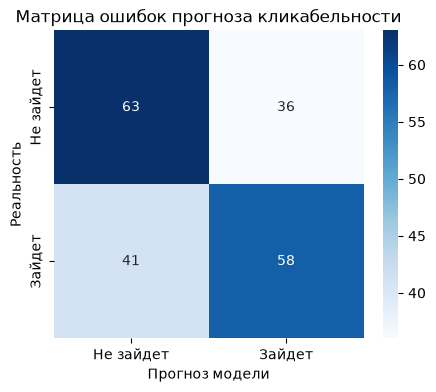

In [46]:
# Разделяем выборку на обучающую и валидационную
X = df_model['title']
y = df_model['is_popular']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# Настраиваем TF-IDF векторизатор (используем символьные n-граммы от 3 до 6 букв)
# Это идеальный способ для работы с транслитом, заменяющий классический лемматизатор!
tfidf = TfidfVectorizer(analyzer='char_wb', ngram_range=(3, 6), max_features=3000)
X_train_tfidf = tfidf.fit_transform(X_train)
X_test_tfidf = tfidf.transform(X_test)

# Обучаем прогностическую модель
model = LogisticRegression(random_state=42, class_weight='balanced')
model.fit(X_train_tfidf, y_train)
preds = model.predict(X_test_tfidf)

print("\n--- ОТЧЕТ ПО КАЧЕСТВУ МОДЕЛИ (МЕТРИКИ ML) ---")
print(classification_report(y_test, preds))

# Строим графическую матрицу ошибок
plt.figure(figsize=(5, 4))
sns.heatmap(confusion_matrix(y_test, preds), annot=True, fmt='d', cmap='Blues',
            xticklabels=['Не зайдет', 'Зайдет'], yticklabels=['Не зайдет', 'Зайдет'])
plt.title('Матрица ошибок прогноза кликабельности')
plt.ylabel('Реальность')
plt.xlabel('Прогноз модели')
plt.show()

## Функция интерактивной проверки зайдёт ли заголовок аудитории Рен-ТВ

In [49]:
def check_future_headline_potential(text_string):
    # Словарь транслитерации букв (соответствует логике генерации url-slug в СМИ)
    translit_dict = {
        'а': 'a', 'б': 'b', 'в': 'v', 'г': 'g', 'д': 'd', 'е': 'e', 'ё': 'e',
        'ж': 'zh', 'з': 'z', 'и': 'i', 'й': 'y', 'к': 'k', 'л': 'l', 'м': 'm',
        'н': 'n', 'о': 'o', 'п': 'p', 'р': 'r', 'с': 's', 'т': 't', 'у': 'u',
        'ф': 'f', 'х': 'kh', 'ц': 'ts', 'ч': 'ch', 'ш': 'sh', 'щ': 'shch',
        'ы': 'y', 'э': 'e', 'ю': 'yu', 'я': 'ya', 'ъ': '', 'ь': ''
    }
    
    # 1. Переводим в нижний регистр и посимвольно конвертируем русский текст
    lower_text = text_string.lower().strip()
    translit_chars = []
    
    for char in lower_text:
        if char in translit_dict:
            translit_chars.append(translit_dict[char])
        elif char.isalnum() or char.isspace():
            # Оставляем цифры, латиницу и пробелы, отбрасывая знаки препинания
            translit_chars.append(char)
            
    clean_translit_text = "".join(translit_chars)
    
    # 2. Векторизуем полученную латиницу через обученный TF-IDF (char_wb n-grams)
    vectorized = tfidf.transform([clean_translit_text])
    
    # 3. Рассчитываем вероятность попадания в класс популярных новостей
    prob = model.predict_proba(vectorized)[0][1] * 100
    
    # Выводим красивый интерактивный результат анализа
    print(f"Входной текст:  \"{text_string}\"")
    print(f"Для модели:     \"{clean_translit_text}\"")
    print(f"Вероятность того, что новость «зайдет»: {prob:.1f}%")
    
    if prob >= 55:
        print("🟢 Модель рекомендует: Отличный выбор ключевых слов! Высокий потенциал просмотров.")
    elif prob <= 45:
        print("🟡 Модель рекомендует: Средний результат (шансы 50 на 50).")
    else:
        print("🔴 Модель рекомендует: Тема слабая. Заголовок вряд ли соберет клики.")
    print("-" * 65)


### Пишем новости

In [50]:
check_future_headline_potential("Путин подписал новый указ о поддержке экономики")
check_future_headline_potential("Прогноз погоды на завтра: ожидаются небольшие дожди")
check_future_headline_potential("Срочно! ВСУ отступают под ударами Минобороны")

Входной текст:  "Путин подписал новый указ о поддержке экономики"
Для модели:     "putin podpisal novyy ukaz o podderzhke ekonomiki"
Вероятность того, что новость «зайдет»: 74.2%
🟢 Модель рекомендует: Отличный выбор ключевых слов! Высокий потенциал просмотров.
-----------------------------------------------------------------
Входной текст:  "Прогноз погоды на завтра: ожидаются небольшие дожди"
Для модели:     "prognoz pogody na zavtra ozhidayutsya nebolshie dozhdi"
Вероятность того, что новость «зайдет»: 49.0%
🔴 Модель рекомендует: Тема слабая. Заголовок вряд ли соберет клики.
-----------------------------------------------------------------
Входной текст:  "Срочно! ВСУ отступают под ударами Минобороны"
Для модели:     "srochno vsu otstupayut pod udarami minoborony"
Вероятность того, что новость «зайдет»: 77.8%
🟢 Модель рекомендует: Отличный выбор ключевых слов! Высокий потенциал просмотров.
-----------------------------------------------------------------


In [51]:
check_future_headline_potential("Обстановка на ближнем востоке совсем плохая")
check_future_headline_potential("С ноября запрещено будет пить безалкогольные жидкости")
check_future_headline_potential("Срочно! Николая Чудотворца заметили в Курске")

Входной текст:  "Обстановка на ближнем востоке совсем плохая"
Для модели:     "obstanovka na blizhnem vostoke sovsem plokhaya"
Вероятность того, что новость «зайдет»: 42.4%
🟡 Модель рекомендует: Средний результат (шансы 50 на 50).
-----------------------------------------------------------------
Входной текст:  "С ноября запрещено будет пить безалкогольные жидкости"
Для модели:     "s noyabrya zapreshcheno budet pit bezalkogolnye zhidkosti"
Вероятность того, что новость «зайдет»: 36.8%
🟡 Модель рекомендует: Средний результат (шансы 50 на 50).
-----------------------------------------------------------------
Входной текст:  "Срочно! Николая Чудотворца заметили в Курске"
Для модели:     "srochno nikolaya chudotvortsa zametili v kurske"
Вероятность того, что новость «зайдет»: 48.6%
🔴 Модель рекомендует: Тема слабая. Заголовок вряд ли соберет клики.
-----------------------------------------------------------------
